In [ ]:
# EDA & Visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu
import requests
import warnings
warnings.filterwarnings('ignore')

Pertanyaan Bisnis

Analisis ini menggunakan dua dataset utama SisaBisa yaitu **dataset bahan makanan**
dan **dataset resep**  untuk menjawab enam pertanyaan bisnis berikut:

| No | Pertanyaan |
|---|---|
| **Q1** | Berapa estimasi umur simpan rata-rata bahan makanan berdasarkan metode penyimpanan? |
| **Q2** | Kategori bahan mana yang paling cepat kedaluwarsa dan berisiko tinggi terbuang? |
| **Q3** | Apakah metode penyimpanan berpengaruh signifikan terhadap umur simpan bahan makanan? |
| **Q4** | Seberapa seimbang distribusi data per metode penyimpanan dan per kategori? |
| **Q5** | Bahan utama apa yang paling sering dipakai di resep? |
| **Q6** | Berapa rata-rata jumlah bahan per resep? |

Tujuan proyek SisaBisa adalah membantu pengguna mengurangi food waste dengan memahami pola umur simpan bahan makanan dan menghubungkannya dengan penggunaan bahan pada resep Indonesia.

In [ ]:
BAHAN_URL = "https://raw.githubusercontent.com/S4nd1Dev/SisaBisa/main/data-science/data/fix_bahan_clean_translate.csv"
RESEP_URL = "https://raw.githubusercontent.com/S4nd1Dev/SisaBisa/main/data-science/data/dataset_resep_format_final.xlsx"

df_bahan = pd.read_csv(BAHAN_URL)

df_resep = pd.read_excel(RESEP_URL)

# **EDA**

In [ ]:
#Dataset Bahan
print(df_bahan['days'].describe())

count     504.000000
mean      147.105159
std       211.930141
min         1.000000
25%         3.000000
50%        30.000000
75%       180.000000
max      1440.000000
Name: days, dtype: float64


Dataset hasil cleaning terdiri dari 504 data dengan umur simpan
berkisar antara 1 hingga 1440 hari. Rata-rata (147.1 hari) jauh
di atas median (30 hari). Selisih yang besar ini mengindikasikan
distribusi right-skewed, artinya sebagian besar bahan memiliki umur
simpan pendek namun ditarik ke atas oleh beberapa bahan yang sangat
tahan lama. Standar deviasi yang tinggi (212.7 hari) mencerminkan
variasi umur simpan yang sangat besar antar bahan.

In [ ]:
#Distribusi Metode Penyimpanan
storage_count = df_bahan['storage'].value_counts()
print(storage_count)
print(f'\nTotal: {storage_count.sum()} baris')

storage
Freezer         168
Kulkas          168
Suhu Ruangan    168
Name: count, dtype: int64

Total: 504 baris


Distribusi data per metode penyimpanan sangat seimbang dimana masing-masing
storage memiliki tepat 166 baris (33.3%). Keseimbangan ini terjadi
karena setiap bahan dalam dataset memiliki data di ketiga metode
penyimpanan sekaligus, sehingga tidak ada potensi bias storage dalam
analisis selanjutnya.

In [ ]:
#Distribusi Kategori Bahan
cat_count = df_bahan['category'].value_counts()
print(cat_count)
print(f'\nTotal kategori: {len(cat_count)}')
print(f'Total bahan unik: {df_bahan["item"].nunique()}')

category
Sayuran                                 177
Bumbu, Saus & Makanan Kalengan           78
Hidangan laut                            75
Daging                                   42
Makanan Tahan Lama di Rak                39
Produk Susu & Telur                      39
Buah-buahan                              33
Biji-bijian, Kacang-kacangan & Pasta     21
Name: count, dtype: int64

Total kategori: 8
Total bahan unik: 168


Dataset mencakup 8 kategori dengan 168 bahan unik. Sayuran mendominasi
dengan 177 data (35.5%), diikuti Bumbu, Saus & Makanan Kalengan (78
data) dan Hidangan Laut (75 data). Biji-bijian, Kacang-kacangan &
Pasta memiliki data paling sedikit (21 data). Ketimpangan antar
kategori ini terjadi karena keragaman bahan yang memang
berbeda-beda dalam masakan Indonesia.

In [ ]:
#Range Umur Simpan
print(f'Minimum : {df_bahan["days"].min()} hari')
print(f'Maximum : {df_bahan["days"].max()} hari')
print(f'Rata-rata: {df_bahan["days"].mean():.1f} hari')
print(f'Median  : {df_bahan["days"].median():.1f} hari')
print(f'Std Dev : {df_bahan["days"].std():.1f} hari')
print()

Minimum : 1 hari
Maximum : 1440 hari
Rata-rata: 147.1 hari
Median  : 30.0 hari
Std Dev : 211.9 hari



Umur simpan minimum 1 hari dan maksimum 1440 hari menunjukkan rentang
yang sangat lebar. Median 30 hari berarti setengah bahan dalam dataset
kadaluarsa dalam sebulan atau kurang, dimana ini memperkuat urgensi fitur
pemantauan dan notifikasi SisaBisa. Std Dev 211.9 hari yang sangat
besar mengkonfirmasi bahwa tidak ada satu nilai umur simpan yang
representatif untuk semua bahan dimana estimasi harus dilakukan per bahan
dan per metode penyimpanan.

In [ ]:
#Umur Simpan per Metode Penyimpanan
storage_order = ['Suhu Ruangan', 'Kulkas', 'Freezer']
storage_stats = df_bahan.groupby('storage')['days'].agg(
    Rata_rata = 'mean',
    Median    = 'median',
    Std_Dev   = 'std',
    Min       = 'min',
    Max       = 'max',
    Jumlah    = 'count'
).reindex(storage_order).round(1)
print(storage_stats.to_string())

              Rata_rata  Median  Std_Dev  Min   Max  Jumlah
storage                                                    
Suhu Ruangan       61.5     2.0    147.4    1   999     168
Kulkas             94.8     7.0    177.7    1   999     168
Freezer           285.0   180.0    229.6   14  1440     168


Freezer memiliki median umur simpan tertinggi (180 hari), diikuti
Kulkas (7 hari) dan Suhu Ruangan (2 hari). Perbedaan yang sangat
besar antara Suhu Ruangan dan Freezer yaitu dari 2 hari menjadi 180 hari menunjukkan betapa besar pengaruh metode penyimpanan terhadap
ketahanan bahan makanan. Nilai rata-rata yang jauh di atas median
di semua storage mengkonfirmasi distribusi right-skewed.

In [ ]:
#Umur Simpan per Kategori
cat_stats = df_bahan.groupby('category')['days'].agg(
    Rata_rata = 'mean',
    Median    = 'median',
    Min       = 'min',
    Max       = 'max',
    Jumlah    = 'count'
).sort_values('Median').round(1)
print(cat_stats.to_string())

                                      Rata_rata  Median  Min   Max  Jumlah
category                                                                  
Hidangan laut                              73.9     2.0    1   540      75
Daging                                     72.1     3.0    1   360      42
Sayuran                                    78.0    14.0    1   540     177
Buah-buahan                                81.7    14.0    2   360      33
Produk Susu & Telur                        91.9    30.0    1   365      39
Biji-bijian, Kacang-kacangan & Pasta      292.2   180.0    1   730      21
Bumbu, Saus & Makanan Kalengan            238.5   180.0    1   730      78
Makanan Tahan Lama di Rak                 532.0   365.0   30  1440      39


Kategori Makanan Tahan Lama di Rak memiliki umur simpan paling tinggi dengan rata-rata 532 hari, sedangkan Hidangan laut dan Daging memiliki umur simpan paling pendek dengan median hanya 2–3 hari. Hal ini menunjukkan bahwa bahan protein hewani segar lebih cepat rusak dibanding bahan shelf-stable seperti makanan kalengan, pasta, atau bahan kering. Sementara itu, kategori Sayuran, Buah-buahan, serta Produk Susu & Telur memiliki umur simpan menengah dengan variasi umur simpan yang cukup beragam antar bahan.

In [ ]:
#Median Umur Simpan per Katgeori dan Metode Penyimpanan
pivot = df_bahan.groupby(['category', 'storage'])['days'].median().unstack()
pivot = pivot.reindex(columns=storage_order)
pivot = pivot.sort_values('Kulkas')
print(pivot.to_string())

storage                               Suhu Ruangan  Kulkas  Freezer
category                                                           
Hidangan laut                                  1.0     2.0    180.0
Daging                                         1.0     3.0    165.0
Sayuran                                        2.0     7.0    180.0
Buah-buahan                                    5.0     7.0    240.0
Produk Susu & Telur                            1.0    21.0    120.0
Bumbu, Saus & Makanan Kalengan                30.0   180.0    360.0
Biji-bijian, Kacang-kacangan & Pasta         120.0   360.0    720.0
Makanan Tahan Lama di Rak                    360.0   360.0    720.0


Median umur simpan menunjukkan bahwa metode penyimpanan sangat memengaruhi ketahanan bahan makanan. Pada kategori Hidangan laut, Daging, dan Produk Susu & Telur, umur simpan di suhu ruangan hanya sekitar 1 hari, tetapi meningkat cukup signifikan saat disimpan di kulkas atau freezer. Sementara itu, kategori seperti Biji-bijian, Kacang-kacangan & Pasta serta Makanan Tahan Lama di Rak memiliki umur simpan paling panjang di semua metode penyimpanan, terutama pada freezer yang dapat mencapai median 720 hari. Hal ini menunjukkan bahwa freezer merupakan metode penyimpanan paling efektif untuk memperpanjang umur simpan hampir seluruh kategori bahan.

In [ ]:
# Preprocessing — groupby per resep
def clean_and_split(text):
    if pd.isna(text):
        return []
    return [b.strip().lower() for b in str(text).split(',') if b.strip()]

df_resep['bahan_list'] = df_resep['bahan'].apply(clean_and_split)

df_grouped = df_resep.groupby('nama_menu')['bahan_list'].sum().reset_index()
df_grouped['bahan_list'] = df_grouped['bahan_list'].apply(lambda x: list(set(x)))
df_grouped['jumlah_bahan'] = df_grouped['bahan_list'].apply(len)

print(f'Total resep unik : {df_grouped["nama_menu"].nunique()}')
print(f'Total bahan unik : {df_resep["bahan"].nunique()}')
print()
print(df_grouped.head())

Total resep unik : 11790
Total bahan unik : 10729

                                    nama_menu  \
0  AYAM BAKAR KECAP for breakfast diet GM day   
1   AYAM GORENG BUMBU SEDERHANA pastinya enak   
2                                 AYAM ungkep   
3                Abon Ikan Cakalang ala Bumil   
4                           Abon Ikan Tongkol   

                                          bahan_list  jumlah_bahan  
0  [daun salam, kecap manis, kemiri, lengkuas, ga...            12  
1  [lengkuas, garam, jahe, bawang putih, ayam, ba...             7  
2  [ketumbar, garam, jahe, bawang putih, ayam, ku...             9  
3  [minyak goreng, cabai rawit, garam, lemon, baw...             9  
4  [daun salam, ketumbar, cabai merah, lengkuas, ...             9  


In [ ]:
# Distribusi jumlah bahan per resep
print('=== Distribusi Jumlah Bahan per Resep ===')
print(df_grouped['jumlah_bahan'].describe().round(1))
print()
print(f'Resep dengan < 3 bahan : {(df_grouped["jumlah_bahan"] < 3).sum()}')
print(f'Resep dengan 3-5 bahan : {((df_grouped["jumlah_bahan"] >= 3) & (df_grouped["jumlah_bahan"] <= 5)).sum()}')
print(f'Resep dengan 6-10 bahan: {((df_grouped["jumlah_bahan"] >= 6) & (df_grouped["jumlah_bahan"] <= 10)).sum()}')
print(f'Resep dengan > 10 bahan: {(df_grouped["jumlah_bahan"] > 10).sum()}')

=== Distribusi Jumlah Bahan per Resep ===
count    11790.0
mean        10.4
std          5.3
min          1.0
25%          7.0
50%         10.0
75%         13.0
max         51.0
Name: jumlah_bahan, dtype: float64

Resep dengan < 3 bahan : 1093
Resep dengan 3-5 bahan : 770
Resep dengan 6-10 bahan: 4377
Resep dengan > 10 bahan: 5550


Dataset resep terdiri dari **11.790 resep** dengan rata-rata
**10.4 bahan per resep** dan median **10 bahan**. Distribusi jumlah
bahan relatif normal.

Rincian distribusi:
- **1.093 resep** memiliki < 3 bahan
- **770 resep** memiliki 3–5 bahan
- **4.377 resep** memiliki 6–10 bahan
- **5.550 resep** memiliki > 10 bahan

Jumlah bahan berkisar antara 1 hingga 51 bahan per resep. Mayoritas
resep (84.9%) menggunakan minimal 6 bahan, menunjukkan bahwa resep
dalam dataset cukup kompleks dan kaya variasi bahan dimana merupakan kondisi yang
baik untuk melatih model rekomendasi resep.

In [ ]:
from collections import Counter

all_ingredients = [bahan for sublist in df_grouped['bahan_list'] for bahan in sublist]
bahan_counts    = Counter(all_ingredients)
df_bahan_freq   = pd.DataFrame(bahan_counts.items(), columns=['bahan', 'frekuensi']).sort_values('frekuensi', ascending=False)

print('=== 15 Bahan Paling Sering Muncul di Resep ===')
print(df_bahan_freq.head(15).to_string(index=False))
print(f'\nTotal bahan unik: {len(df_bahan_freq)}')

=== 15 Bahan Paling Sering Muncul di Resep ===
        bahan  frekuensi
 bawang putih       8915
        garam       8044
 bawang merah       7053
penyedap rasa       5322
  cabai rawit       4632
          air       4311
minyak goreng       3926
   lada putih       3312
  cabai merah       3191
   telur ayam       2901
  kecap manis       2881
   gula pasir       2832
  tomat merah       2711
         jahe       2667
     lengkuas       2398

Total bahan unik: 586


In [ ]:
# Daftar bumbu dasar yang dikecualikan
bumbu_dasar = {
    'garam', 'penyedap rasa', 'air', 'minyak goreng', 'lada putih',
    'lada hitam', 'merica', 'gula pasir', 'gula merah', 'kecap manis',
    'kecap asin', 'bawang putih', 'bawang merah', 'bawang bombai',
    'jahe', 'lengkuas', 'serai', 'kemiri', 'kunyit', 'ketumbar',
    'daun salam', 'daun jeruk', 'daun bawang', 'cabai rawit',
    'cabai merah', 'cabai hijau', 'cabai keriting', 'tomat merah',
    'jintan', 'kapulaga', 'kayu manis', 'cengkeh', 'pala',
    'bunga lawang', 'asam jawa', 'terasi', 'kencur', 'air jeruk',
    'minyak wijen', 'saus tiram', 'saus tomat', 'saus sambal',
    'mayones', 'cuka', 'tepung terigu', 'tepung maizena', 'tepung serbaguna',
    'tepung tapioka', 'bumbu', 'susu kental manis', 'santan', 'gula','jeruk nipis',
    'margarin', 'cengkih', 'mentega', 'bawang goreng', 'beras'
}

# Filter bahan utama saja
df_bahan_utama = df_bahan_freq[~df_bahan_freq['bahan'].isin(bumbu_dasar)]

print('=== 15 Bahan Utama Paling Sering Muncul di Resep ===')
print(df_bahan_utama.head(15).to_string(index=False))

=== 15 Bahan Utama Paling Sering Muncul di Resep ===
      bahan  frekuensi
 telur ayam       2901
       tahu       1792
       ayam       1680
      tempe       1543
     wortel       1236
    kambing       1034
daging sapi       1032
    kentang        710
      udang        597
    seledri        569
      kubis        545
     buncis        397
       toge        326
    kemangi        320
      sosis        258


Hasil analisis menunjukkan bahwa resep Indonesia didominasi oleh bumbu dasar seperti bawang putih, garam, bawang merah, cabai, dan berbagai rempah. Bawang putih menjadi bahan paling sering digunakan dengan frekuensi 8.915 kali. Hal ini menunjukkan bahwa sebagian besar masakan Indonesia memiliki pola bumbu yang mirip dan kaya cita rasa. Tingginya penggunaan cabai, jahe, lengkuas, dan kecap manis juga mencerminkan karakter masakan Indonesia yang gurih, pedas, dan berbumbu kuat.

Namun, setelah bumbu dasar dihilangkan, bahan utama yang paling sering muncul adalah telur ayam, tahu, ayam, dan tempe. Hal ini menunjukkan bahwa sumber protein yang praktis, murah, dan mudah diolah menjadi pilihan utama dalam masakan sehari-hari. Selain itu, sayuran seperti wortel, kentang, dan kubis juga cukup sering digunakan sebagai pelengkap masakan. Hasil ini dapat dimanfaatkan untuk sistem rekomendasi resep karena bahan-bahan tersebut cenderung paling umum tersedia di rumah tangga pengguna.

In [ ]:
# Statistik jumlah bahan per resep
print('===  Statistik Jumlah Bahan per Resep ===')
stats = df_grouped['jumlah_bahan'].agg(['mean','median','min','max','std']).round(1)
stats.index = ['Rata-rata', 'Median', 'Min', 'Max', 'Std Dev']
print(stats.to_string())

===  Statistik Jumlah Bahan per Resep ===
Rata-rata    10.4
Median       10.0
Min           1.0
Max          51.0
Std Dev       5.3


Rata-rata dan median jumlah bahan per resep hampir sama yaitu dengan rata-rata 10.4 dan media 10 hal ini menunjukkan distribusi yang **relatif simetris** dan tidak terpengaruh outlier secara signifikan.

Jumlah bahan berkisar antara **1 hingga 51 bahan** per resep dengan
standar deviasi 5.3, artinya sebagian besar
resep memiliki jumlah bahan yang tidak terlalu jauh dari rata-rata.


# **Visualisasi dan Explanatory Analysis**

In [ ]:
# === Global Style ===
PALETTE = {
    'Suhu Ruangan': '#F4A261',
    'Kulkas'      : '#457B9D',
    'Freezer'     : '#A8DADC'
}
COLOR_DANGER  = '#E63946'
COLOR_WARNING = '#F4A261'
COLOR_SAFE    = '#2A9D8F'
COLOR_PRIMARY = '#1D3557'

plt.rcParams.update({
    'figure.dpi'        : 130,
    'font.family'       : 'sans-serif',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
})

print('✅ Library siap digunakan')

✅ Library siap digunakan


## 📊 1 — Berapa estimasi umur simpan rata-rata per metode penyimpanan?


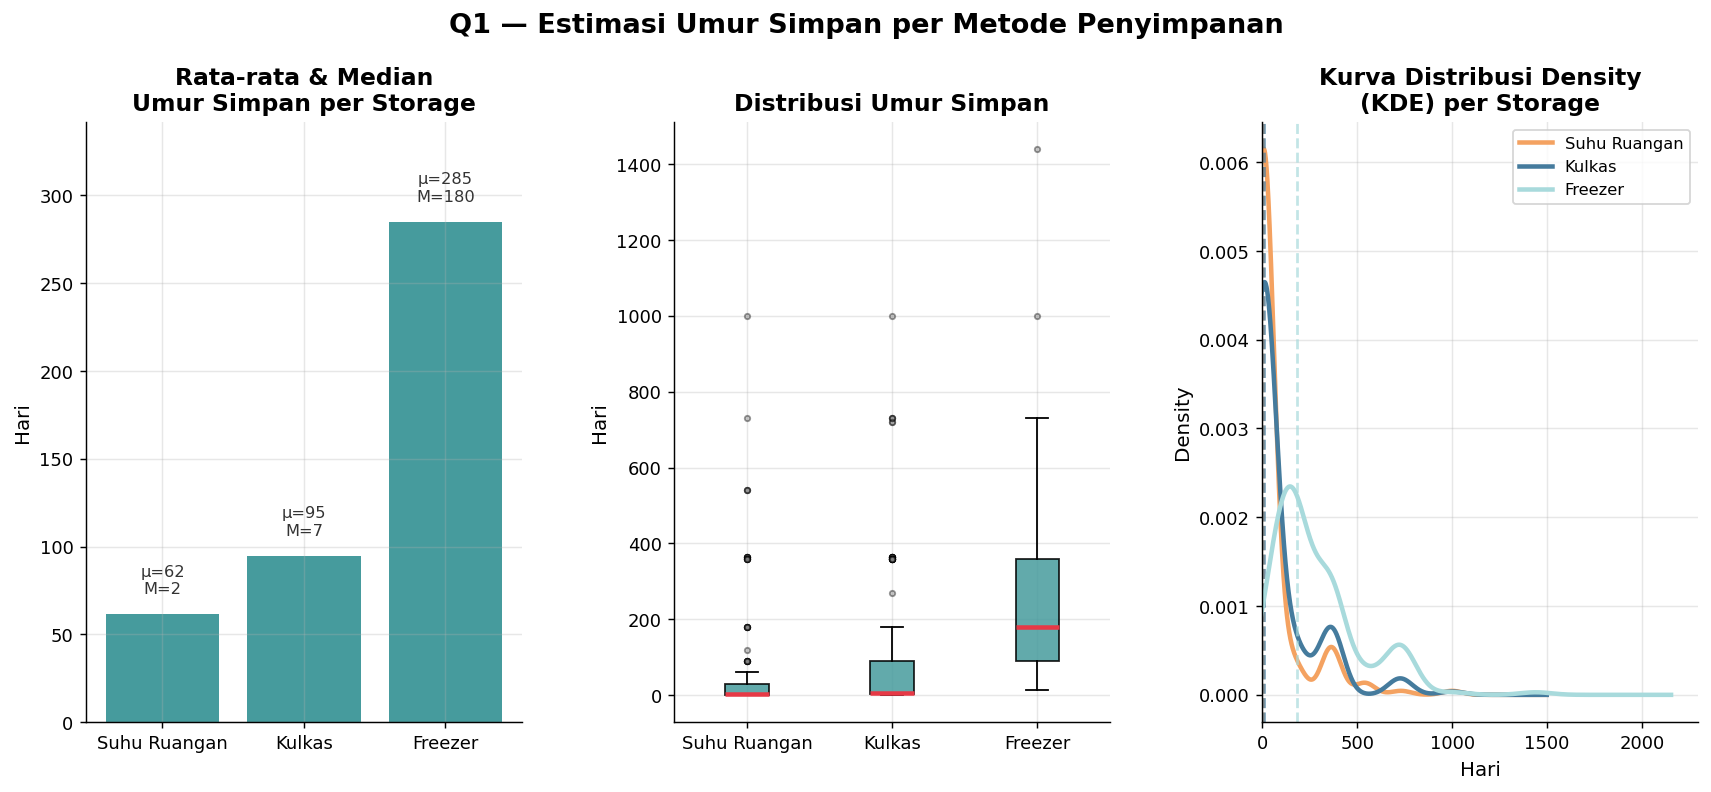

In [ ]:
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# Bar chart rata-rata + error bar
means = storage_stats.reindex(storage_order)['Rata_rata']
stds  = storage_stats.reindex(storage_order)['Std_Dev']
bars = ax1.bar(storage_order, means, color='#469B9D')

medians = storage_stats.reindex(storage_order)['Median']
for i, (m, md) in enumerate(zip(means, medians)):
    ax1.text(i, m + 10, f'μ={m:.0f}\nM={md:.0f}',
             ha='center', va='bottom',
             fontsize=9, color='#333')
ax1.set_title('Rata-rata & Median\nUmur Simpan per Storage')
ax1.set_ylabel('Hari')
ax1.set_xlabel('')
ax1.set_ylim(0, means.max() * 1.2)
ax1.tick_params(axis='x', labelsize=10)

# Boxplot
data_groups = [df_bahan[df_bahan['storage'] == s]['days'].values for s in storage_order]
bp = ax2.boxplot(data_groups, labels=storage_order, patch_artist=True,
                 medianprops=dict(color=COLOR_DANGER, linewidth=2.5),
                 flierprops=dict(marker='o', markerfacecolor='gray',
                                 markersize=3, alpha=0.4, linestyle='none'))
for patch in bp['boxes']:
    patch.set_facecolor('#469B9D')
    patch.set_alpha(0.85)

ax2.set_title('Distribusi Umur Simpan')
ax2.set_ylabel('Hari')
ax2.tick_params(axis='x', labelsize=10)

# --- KDE ---
for s in storage_order:
    subset = df_bahan[df_bahan['storage'] == s]['days']
    subset.plot.kde(ax=ax3, label=s, color=PALETTE[s], linewidth=2.5)
    ax3.axvline(subset.median(), color=PALETTE[s], linestyle='--',
                linewidth=1.5, alpha=0.7)

ax3.set_title('Kurva Distribusi Density\n(KDE) per Storage')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Density')
ax3.legend(fontsize=9)
ax3.set_xlim(left=0)

fig.suptitle('Q1 — Estimasi Umur Simpan per Metode Penyimpanan',
             fontsize=15, fontweight='bold', y=1.02)
plt.savefig('q1_storage_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

Visualisasi menunjukkan bahwa metode penyimpanan memiliki pengaruh besar terhadap estimasi umur simpan bahan makanan. Berdasarkan grafik rata-rata dan median, penyimpanan menggunakan freezer memberikan umur simpan paling panjang dengan rata-rata sekitar 285 hari dan median 180 hari. Sementara itu, penyimpanan di suhu ruangan memiliki umur simpan paling pendek dengan median hanya sekitar 2 hari.

Boxplot juga menunjukkan bahwa distribusi umur simpan pada freezer jauh lebih tinggi dibanding metode lainnya, meskipun terdapat beberapa outlier dengan umur simpan sangat panjang. Selain itu, kurva KDE memperlihatkan bahwa sebagian besar bahan pada suhu ruangan dan kulkas terkonsentrasi pada umur simpan pendek, sedangkan freezer memiliki distribusi yang lebih menyebar ke umur simpan panjang.

Hal ini menunjukkan bahwa metode penyimpanan sangat memengaruhi ketahanan bahan makanan, dan freezer menjadi metode paling efektif untuk memperpanjang umur simpan serta berpotensi membantu mengurangi food waste.


## 📊 2 — Kategori bahan mana yang paling cepat kedaluwarsa?


In [ ]:
# Klasifikasi risiko
def classify_risk(median):
    if median <= 7:
        return 'Risiko Tinggi (≤7 hari)'
    elif median <= 30:
        return 'Risiko Sedang (8-30 hari)'
    else:
        return 'Risiko Rendah (>30 hari)'

cat_stats['Risiko'] = cat_stats['Median'].apply(classify_risk)
print('=== Statistik Umur Simpan per Kategori ===')
print(cat_stats.to_string())

=== Statistik Umur Simpan per Kategori ===
                                      Rata_rata  Median  Min   Max  Jumlah                     Risiko
category                                                                                             
Hidangan laut                              73.9     2.0    1   540      75    Risiko Tinggi (≤7 hari)
Daging                                     72.1     3.0    1   360      42    Risiko Tinggi (≤7 hari)
Sayuran                                    78.0    14.0    1   540     177  Risiko Sedang (8-30 hari)
Buah-buahan                                81.7    14.0    2   360      33  Risiko Sedang (8-30 hari)
Produk Susu & Telur                        91.9    30.0    1   365      39  Risiko Sedang (8-30 hari)
Biji-bijian, Kacang-kacangan & Pasta      292.2   180.0    1   730      21   Risiko Rendah (>30 hari)
Bumbu, Saus & Makanan Kalengan            238.5   180.0    1   730      78   Risiko Rendah (>30 hari)
Makanan Tahan Lama di Rak              

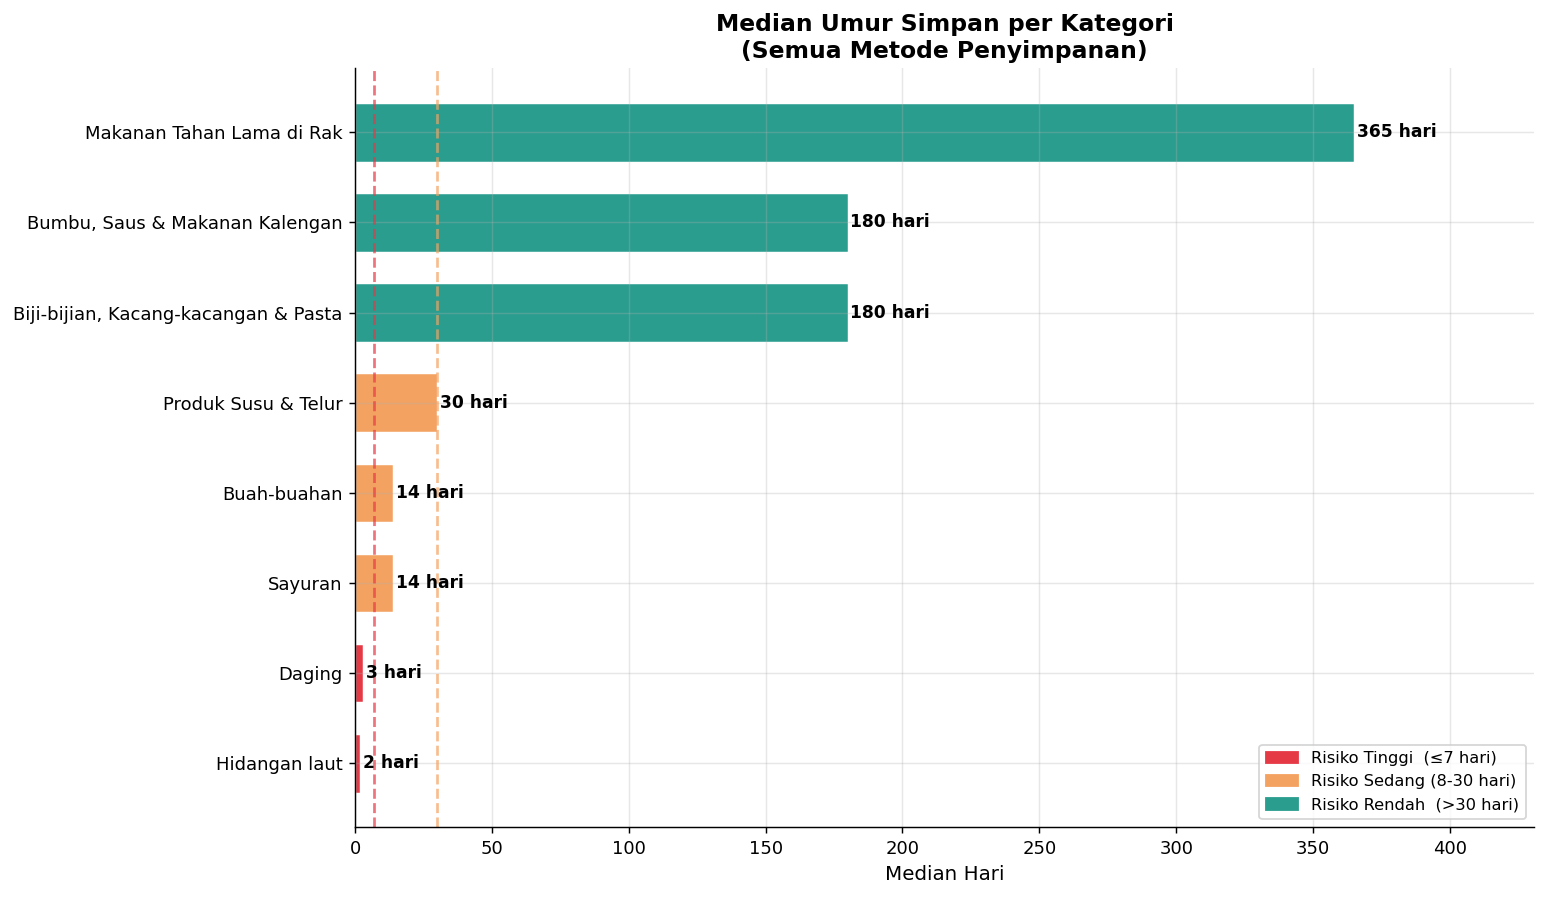

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

risk_colors = {
    'Risiko Tinggi (≤7 hari)'  : COLOR_DANGER,
    'Risiko Sedang (8-30 hari)': COLOR_WARNING,
    'Risiko Rendah (>30 hari)' : COLOR_SAFE
}
bar_colors = cat_stats['Risiko'].map(risk_colors)

bars = ax.barh(cat_stats.index, cat_stats['Median'],
               color=bar_colors, edgecolor='white', linewidth=0.8, height=0.65)

for bar, val, risk in zip(bars, cat_stats['Median'], cat_stats['Risiko']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} hari', va='center', fontsize=9.5, fontweight='bold')

ax.axvline(7,  color=COLOR_DANGER,  linestyle='--', linewidth=1.5,
           alpha=0.7, label='Threshold Tinggi (7 hari)')
ax.axvline(30, color=COLOR_WARNING, linestyle='--', linewidth=1.5,
           alpha=0.7, label='Threshold Sedang (30 hari)')

legend_patches = [
    mpatches.Patch(color=COLOR_DANGER,  label='Risiko Tinggi  (≤7 hari)'),
    mpatches.Patch(color=COLOR_WARNING, label='Risiko Sedang (8-30 hari)'),
    mpatches.Patch(color=COLOR_SAFE,    label='Risiko Rendah  (>30 hari)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax.set_title('Median Umur Simpan per Kategori\n(Semua Metode Penyimpanan)')
ax.set_xlabel('Median Hari')
ax.set_xlim(0, cat_stats['Median'].max() * 1.18)

plt.tight_layout()
plt.show()

Berdasarkan median umur simpan per kategori, Hidangan laut menjadi kategori bahan yang paling cepat kadaluwarsa dengan median umur simpan hanya 2 hari, diikuti oleh Daging dengan median 3 hari. Hal ini menunjukkan bahwa bahan protein hewani segar memiliki risiko kerusakan paling tinggi dibanding kategori lainnya, terutama jika tidak segera disimpan atau diolah dengan benar.

Sebaliknya, kategori seperti Makanan Tahan Lama di Rak, Bumbu, Saus & Makanan Kalengan, serta Biji-bijian, Kacang-kacangan & Pasta memiliki median umur simpan jauh lebih panjang, yaitu 180–365 hari. Perbedaan ini menunjukkan bahwa jenis bahan sangat memengaruhi estimasi umur simpan dan tingkat risiko food waste.

Hasil analisis ini dapat dimanfaatkan dalam sistem prioritas memasak, di mana bahan dengan umur simpan paling pendek seperti seafood, daging, sayuran, dan produk susu sebaiknya diprioritaskan untuk digunakan terlebih dahulu agar mengurangi potensi pemborosan makanan.

## 📊 3 — Apakah metode penyimpanan berpengaruh signifikan terhadap umur simpan?

In [ ]:
from scipy.stats import kruskal, mannwhitneyu

suhu    = df_bahan[df_bahan['storage'] == 'Suhu Ruangan']['days'].values
kulkas  = df_bahan[df_bahan['storage'] == 'Kulkas']['days'].values
freezer = df_bahan[df_bahan['storage'] == 'Freezer']['days'].values
# Kruskal-Wallis (uji non-parametrik karena distribusi tidak normal)
stat_kw, p_kw = kruskal(suhu, kulkas, freezer)

print('=== Uji Kruskal-Wallis (Keseluruhan) ===')
print(f'H-statistic : {stat_kw:.4f}')
print(f'p-value     : {p_kw:.6f}')
print(f'Kesimpulan  : {"SIGNIFIKAN ✅" if p_kw < 0.05 else "TIDAK SIGNIFIKAN ❌"} (α = 0.05)')
print()

# Post-hoc: Mann-Whitney U per pasangan
print('=== Post-hoc Mann-Whitney U (Perbandingan Berpasangan) ===')
pairs = [
    ('suhu ruangan', 'kulkas',   suhu,    kulkas),
    ('suhu ruangan', 'freezer',  suhu,    freezer),
    ('kulkas',       'freezer',  kulkas,  freezer),
]
results = []
for a, b, ga, gb in pairs:
    u, p = mannwhitneyu(ga, gb, alternative='two-sided')
    sig  = '✅ Signifikan' if p < 0.05 else '❌ Tidak Signifikan'
    results.append({'Pasangan': f'{a} vs {b}', 'U-statistic': round(u, 2), 'p-value': round(p, 6), 'Hasil': sig})
    print(f'{a:>14} vs {b:<14} | U={u:.2f} | p={p:.6f} | {sig}')

df_posthoc = pd.DataFrame(results)

=== Uji Kruskal-Wallis (Keseluruhan) ===
H-statistic : 200.3987
p-value     : 0.000000
Kesimpulan  : SIGNIFIKAN ✅ (α = 0.05)

=== Post-hoc Mann-Whitney U (Perbandingan Berpasangan) ===
  suhu ruangan vs kulkas         | U=8762.50 | p=0.000000 | ✅ Signifikan
  suhu ruangan vs freezer        | U=3027.00 | p=0.000000 | ✅ Signifikan
        kulkas vs freezer        | U=4656.50 | p=0.000000 | ✅ Signifikan


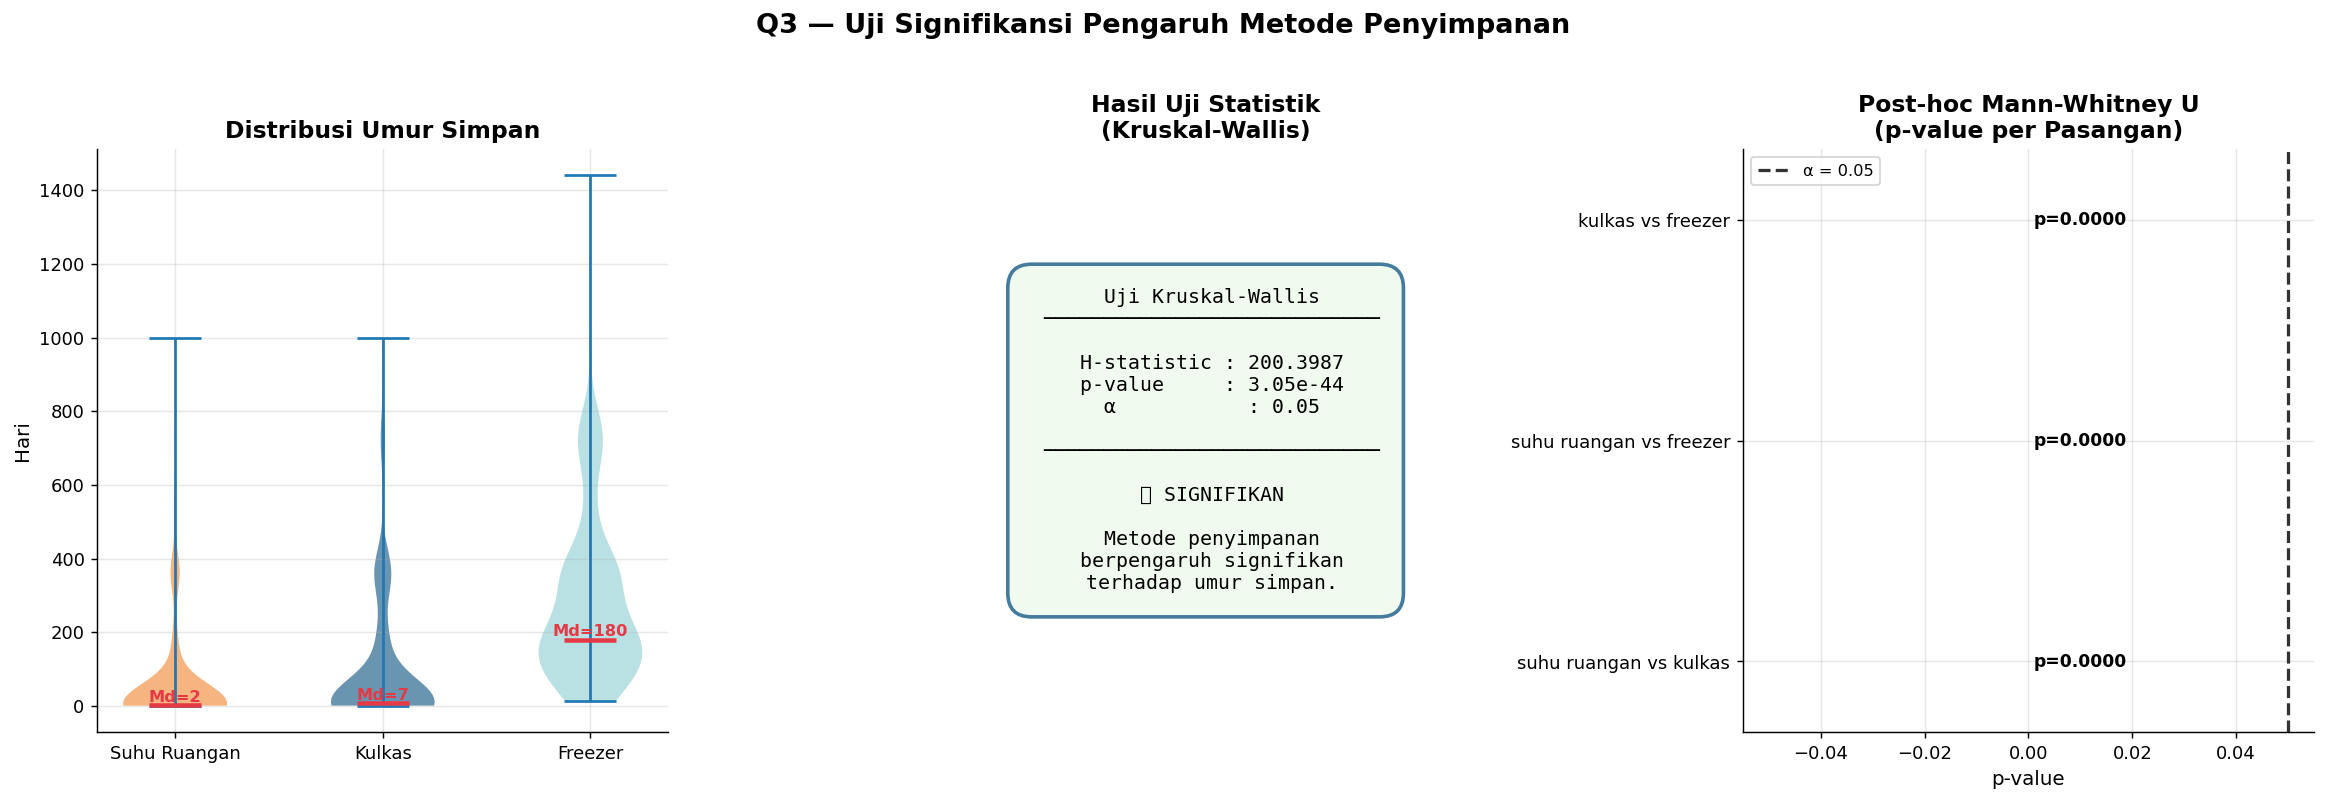

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Plot 1: Violin plot ---
parts = axes[0].violinplot(
    [suhu, kulkas, freezer],
    positions=[1, 2, 3],
    showmedians=True,
    showmeans=False,
    showextrema=True
)
for i, (pc, s) in enumerate(zip(parts['bodies'], storage_order)):
    pc.set_facecolor(PALETTE[s])
    pc.set_alpha(0.8)
parts['cmedians'].set_color(COLOR_DANGER)
parts['cmedians'].set_linewidth(2.5)

axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(storage_order)
axes[0].set_title('Distribusi Umur Simpan')
axes[0].set_ylabel('Hari')

for i, (grp, pos) in enumerate(zip([suhu, kulkas, freezer], [1, 2, 3])):
    axes[0].text(pos, np.median(grp) + 10, f'Md={np.median(grp):.0f}',
                 ha='center', fontsize=9, color=COLOR_DANGER, fontweight='bold')

# --- Plot 2: Hasil Kruskal-Wallis ---
axes[1].axis('off')
result_text = (
    f" Uji Kruskal-Wallis\n"
    f" {'─'*28}\n\n"
    f" H-statistic : {stat_kw:.4f}\n"
    f" p-value     : {p_kw:.2e}\n"
    f" α           : 0.05\n\n"
    f" {'─'*28}\n\n"
    f" {'✅ SIGNIFIKAN' if p_kw < 0.05 else '❌ TIDAK SIGNIFIKAN'}\n\n"
    f" Metode penyimpanan\n"
    f" berpengaruh signifikan\n"
    f" terhadap umur simpan."
)
axes[1].text(0.5, 0.5, result_text, transform=axes[1].transAxes,
             ha='center', va='center', fontsize=11,
             bbox=dict(boxstyle='round,pad=1.2', facecolor='#F1FAEE',
                       edgecolor='#457B9D', linewidth=2),
             fontfamily='monospace')
axes[1].set_title('Hasil Uji Statistik\n(Kruskal-Wallis)')

# --- Plot 3: Post-hoc p-values ---
pair_labels = [r['Pasangan'] for r in results]
pair_pvals  = [r['p-value']  for r in results]
pair_colors = [COLOR_SAFE if p < 0.05 else COLOR_DANGER for p in pair_pvals]

bars3 = axes[2].barh(pair_labels, pair_pvals, color=pair_colors,
                     edgecolor='white', height=0.4)
axes[2].axvline(0.05, color='#333', linestyle='--', linewidth=1.8,
                label='α = 0.05')
axes[2].set_title('Post-hoc Mann-Whitney U\n(p-value per Pasangan)')
axes[2].set_xlabel('p-value')
axes[2].legend(fontsize=9)

for bar, val in zip(bars3, pair_pvals):
    axes[2].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'p={val:.4f}', va='center', fontsize=9.5, fontweight='bold')

fig.suptitle('Q3 — Uji Signifikansi Pengaruh Metode Penyimpanan',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q3_significance.png', bbox_inches='tight', dpi=150)
plt.show()

Berdasarkan hasil uji Kruskal–Wallis, diperoleh p-value sebesar 3.05 × 10⁻⁴⁴, jauh lebih kecil dari α = 0.05. Hal ini menunjukkan bahwa metode penyimpanan memiliki pengaruh yang signifikan terhadap umur simpan bahan makanan. Dengan kata lain, terdapat perbedaan umur simpan yang nyata antara penyimpanan di suhu ruangan, kulkas, dan freezer.

Visualisasi distribusi juga memperlihatkan bahwa freezer memiliki median umur simpan paling tinggi, yaitu sekitar 180 hari, sedangkan suhu ruangan dan kulkas memiliki median jauh lebih rendah, masing-masing sekitar 2 dan 7 hari. Selain itu, hasil uji lanjut Mann–Whitney U menunjukkan seluruh pasangan metode penyimpanan memiliki p-value < 0.05, sehingga setiap metode penyimpanan berbeda signifikan satu sama lain.

Hasil ini memperkuat bahwa pemilihan metode penyimpanan merupakan faktor penting dalam memperpanjang umur simpan bahan makanan dan dapat digunakan sebagai dasar dalam sistem rekomendasi penyimpanan untuk mengurangi food waste.

## 📊 4 — Seberapa seimbang distribusi data per storage dan kategori?

In [ ]:
storage_count  = df_bahan['storage'].value_counts().reindex(storage_order)
category_count = df_bahan['category'].value_counts()

print('=== Distribusi per Metode Penyimpanan ===')
for s, cnt in storage_count.items():
    pct = cnt / len(df_bahan) * 100
    bar = '█' * int(pct / 2)
    print(f'{s:>14} | {bar:<25} {cnt:>4} data ({pct:.1f}%)')

print()
print('=== Distribusi per Kategori ===')
for cat, cnt in category_count.items():
    pct = cnt / len(df_bahan) * 100
    flag = '⚠️ ' if cnt < 20 else ''
    print(f'{flag}{cat:<45} {cnt:>4} data ({pct:.1f}%)')

=== Distribusi per Metode Penyimpanan ===
  Suhu Ruangan | ████████████████           168 data (33.3%)
        Kulkas | ████████████████           168 data (33.3%)
       Freezer | ████████████████           168 data (33.3%)

=== Distribusi per Kategori ===
Sayuran                                        177 data (35.1%)
Bumbu, Saus & Makanan Kalengan                  78 data (15.5%)
Hidangan laut                                   75 data (14.9%)
Daging                                          42 data (8.3%)
Makanan Tahan Lama di Rak                       39 data (7.7%)
Produk Susu & Telur                             39 data (7.7%)
Buah-buahan                                     33 data (6.5%)
Biji-bijian, Kacang-kacangan & Pasta            21 data (4.2%)


In [ ]:
# Imbalance ratio
print('=== Imbalance Ratio per Storage ===')
max_storage = storage_count.max()
for s, cnt in storage_count.items():
    ratio = max_storage / cnt
    flag  = '⚠️  Imbalanced' if ratio > 2 else '✅ Balanced'
    print(f'{s:>14} | {cnt:>4} data | ratio {ratio:.2f}x | {flag}')

print()
print('=== Imbalance Ratio per Kategori ===')
max_category = category_count.max()
for cat, cnt in category_count.items():
    ratio = max_category / cnt
    flag  = '🔴 Sangat Imbalanced' if ratio > 5 else '🟡 Imbalanced' if ratio > 2 else '✅ Balanced'
    print(f'{cat:<45} | {cnt:>4} data | ratio {ratio:.2f}x | {flag}')

=== Imbalance Ratio per Storage ===
  Suhu Ruangan |  168 data | ratio 1.00x | ✅ Balanced
        Kulkas |  168 data | ratio 1.00x | ✅ Balanced
       Freezer |  168 data | ratio 1.00x | ✅ Balanced

=== Imbalance Ratio per Kategori ===
Sayuran                                       |  177 data | ratio 1.00x | ✅ Balanced
Bumbu, Saus & Makanan Kalengan                |   78 data | ratio 2.27x | 🟡 Imbalanced
Hidangan laut                                 |   75 data | ratio 2.36x | 🟡 Imbalanced
Daging                                        |   42 data | ratio 4.21x | 🟡 Imbalanced
Makanan Tahan Lama di Rak                     |   39 data | ratio 4.54x | 🟡 Imbalanced
Produk Susu & Telur                           |   39 data | ratio 4.54x | 🟡 Imbalanced
Buah-buahan                                   |   33 data | ratio 5.36x | 🔴 Sangat Imbalanced
Biji-bijian, Kacang-kacangan & Pasta          |   21 data | ratio 8.43x | 🔴 Sangat Imbalanced


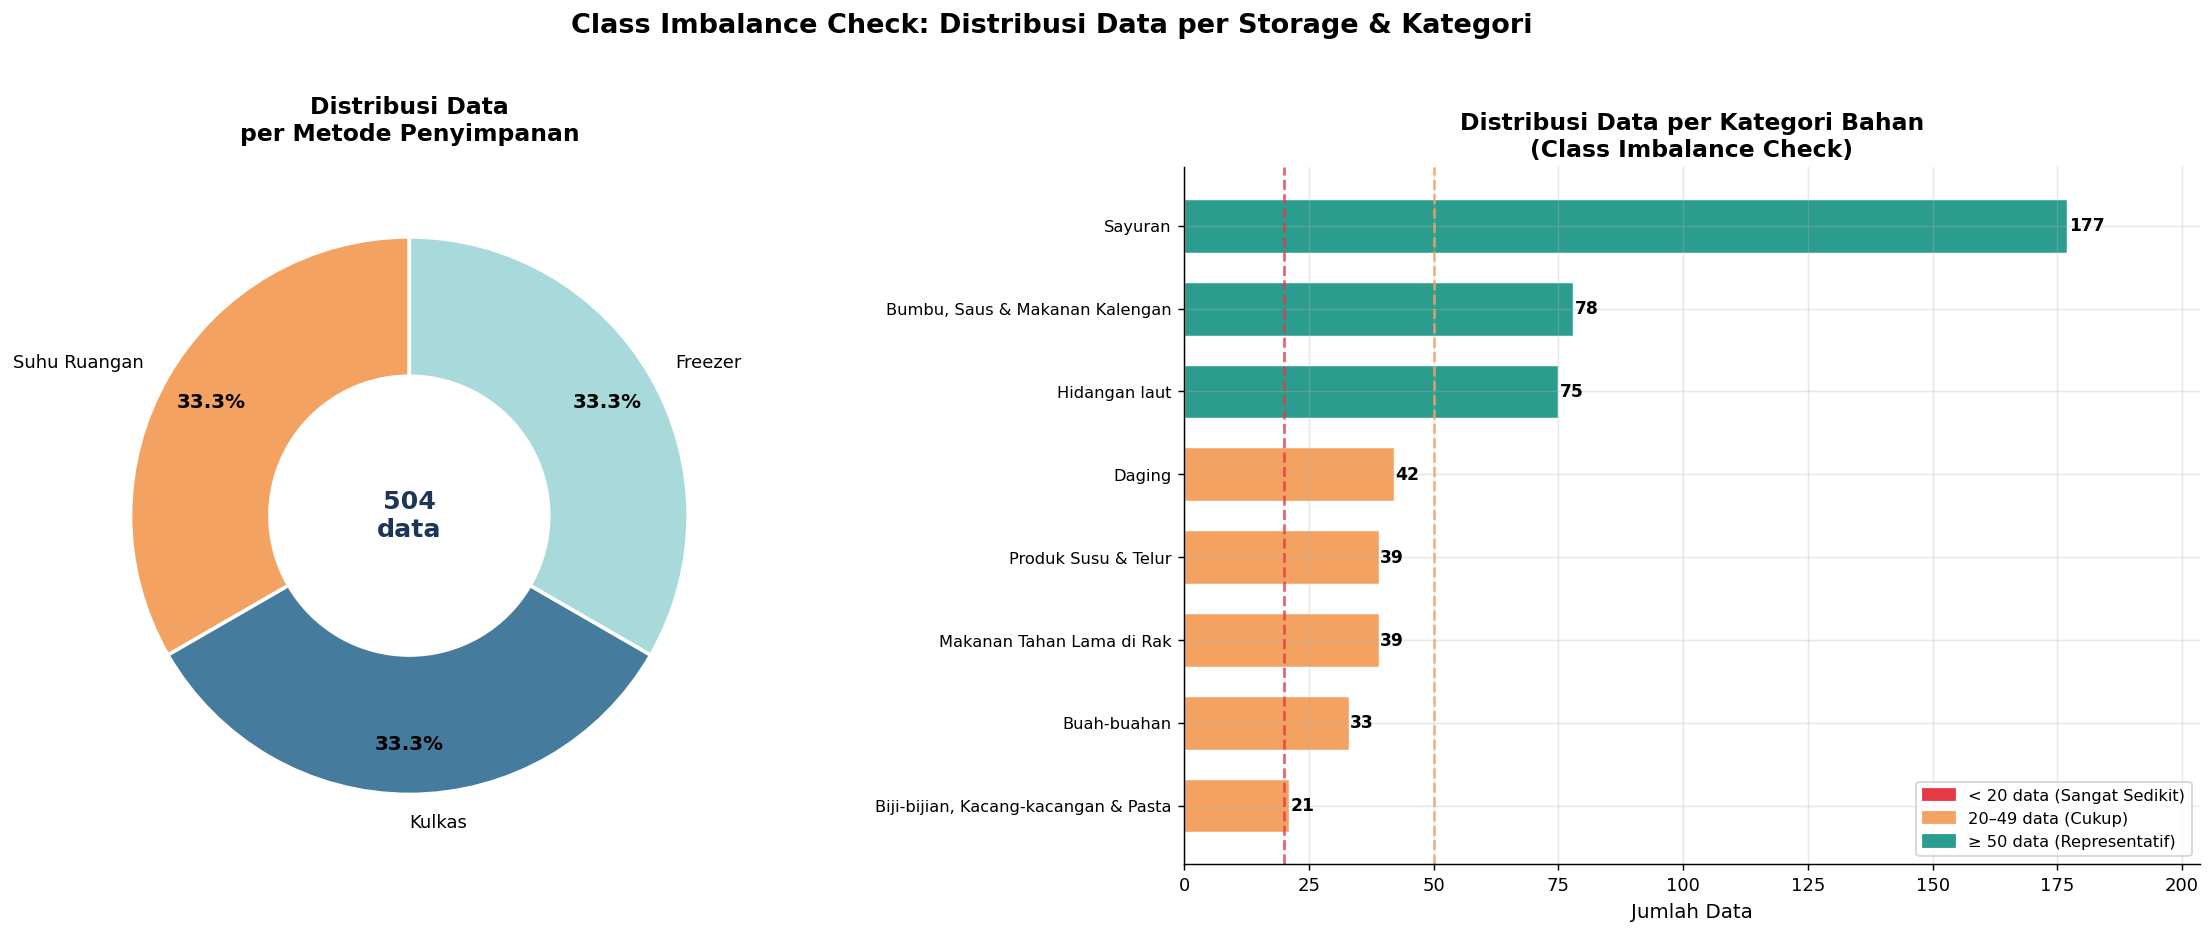

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Donut chart storage ---
wedges, texts, autotexts = axes[0].pie(
    storage_count,
    labels=storage_count.index,
    autopct='%1.1f%%',
    colors=[PALETTE[s] for s in storage_order],
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

# Annotasi jumlah data di tengah
axes[0].text(0, 0, f'{len(df_bahan)}\ndata', ha='center', va='center',
             fontsize=14, fontweight='bold', color=COLOR_PRIMARY)
axes[0].set_title('Distribusi Data\nper Metode Penyimpanan', pad=15)

# --- Plot 2: Bar chart kategori dengan warna ambang batas ---
cat_sorted  = category_count.sort_values(ascending=True)
cat_colors2 = ['#E63946' if v < 20 else '#F4A261' if v < 50 else '#2A9D8F'
               for v in cat_sorted.values]

bars2 = axes[1].barh(cat_sorted.index, cat_sorted.values,
                     color=cat_colors2, edgecolor='white', linewidth=0.8, height=0.65)

for bar, val in zip(bars2, cat_sorted.values):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9.5, fontweight='bold')

# Threshold lines
axes[1].axvline(20, color=COLOR_DANGER,  linestyle='--', linewidth=1.5,
                alpha=0.8, label='Min. threshold (20)')
axes[1].axvline(50, color=COLOR_WARNING, linestyle='--', linewidth=1.5,
                alpha=0.8, label='Threshold sedang (50)')

legend_patches2 = [
    mpatches.Patch(color=COLOR_DANGER,  label='< 20 data (Sangat Sedikit)'),
    mpatches.Patch(color=COLOR_WARNING, label='20–49 data (Cukup)'),
    mpatches.Patch(color=COLOR_SAFE,    label='≥ 50 data (Representatif)'),
]
axes[1].legend(handles=legend_patches2, loc='lower right', fontsize=9)
axes[1].set_title('Distribusi Data per Kategori Bahan\n(Class Imbalance Check)')
axes[1].set_xlabel('Jumlah Data')
axes[1].tick_params(axis='y', labelsize=9)
axes[1].set_xlim(0, cat_sorted.max() * 1.15)

fig.suptitle('Class Imbalance Check: Distribusi Data per Storage & Kategori',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q4_imbalance.png', bbox_inches='tight', dpi=150)
plt.show()

Berdasarkan visualisasi distribusi data, jumlah data pada setiap metode penyimpanan terbagi secara seimbang, yaitu masing-masing sekitar 33.3% dari total 504 data. Hal ini menunjukkan bahwa dataset tidak mengalami class imbalance pada variabel metode penyimpanan, sehingga analisis maupun model yang dibangun nantinya tidak akan cenderung bias terhadap salah satu metode penyimpanan tertentu.

Namun, distribusi data berdasarkan kategori bahan menunjukkan adanya ketidakseimbangan jumlah data antar kategori. Kategori Sayuran memiliki jumlah data paling banyak dengan 177 data, sedangkan kategori seperti Biji-bijian, Kacang-kacangan & Pasta, Buah-buahan, serta Produk Susu & Telur memiliki jumlah data yang lebih sedikit. Meskipun demikian, sebagian besar kategori masih berada pada rentang data yang cukup representatif untuk dianalisis.Hasil ini menunjukkan bahwa dataset sudah cukup baik untuk analisis umur simpan berdasarkan metode penyimpanan,

## 📊 5 — Bahan  Paling Sering Dipakai di Resep

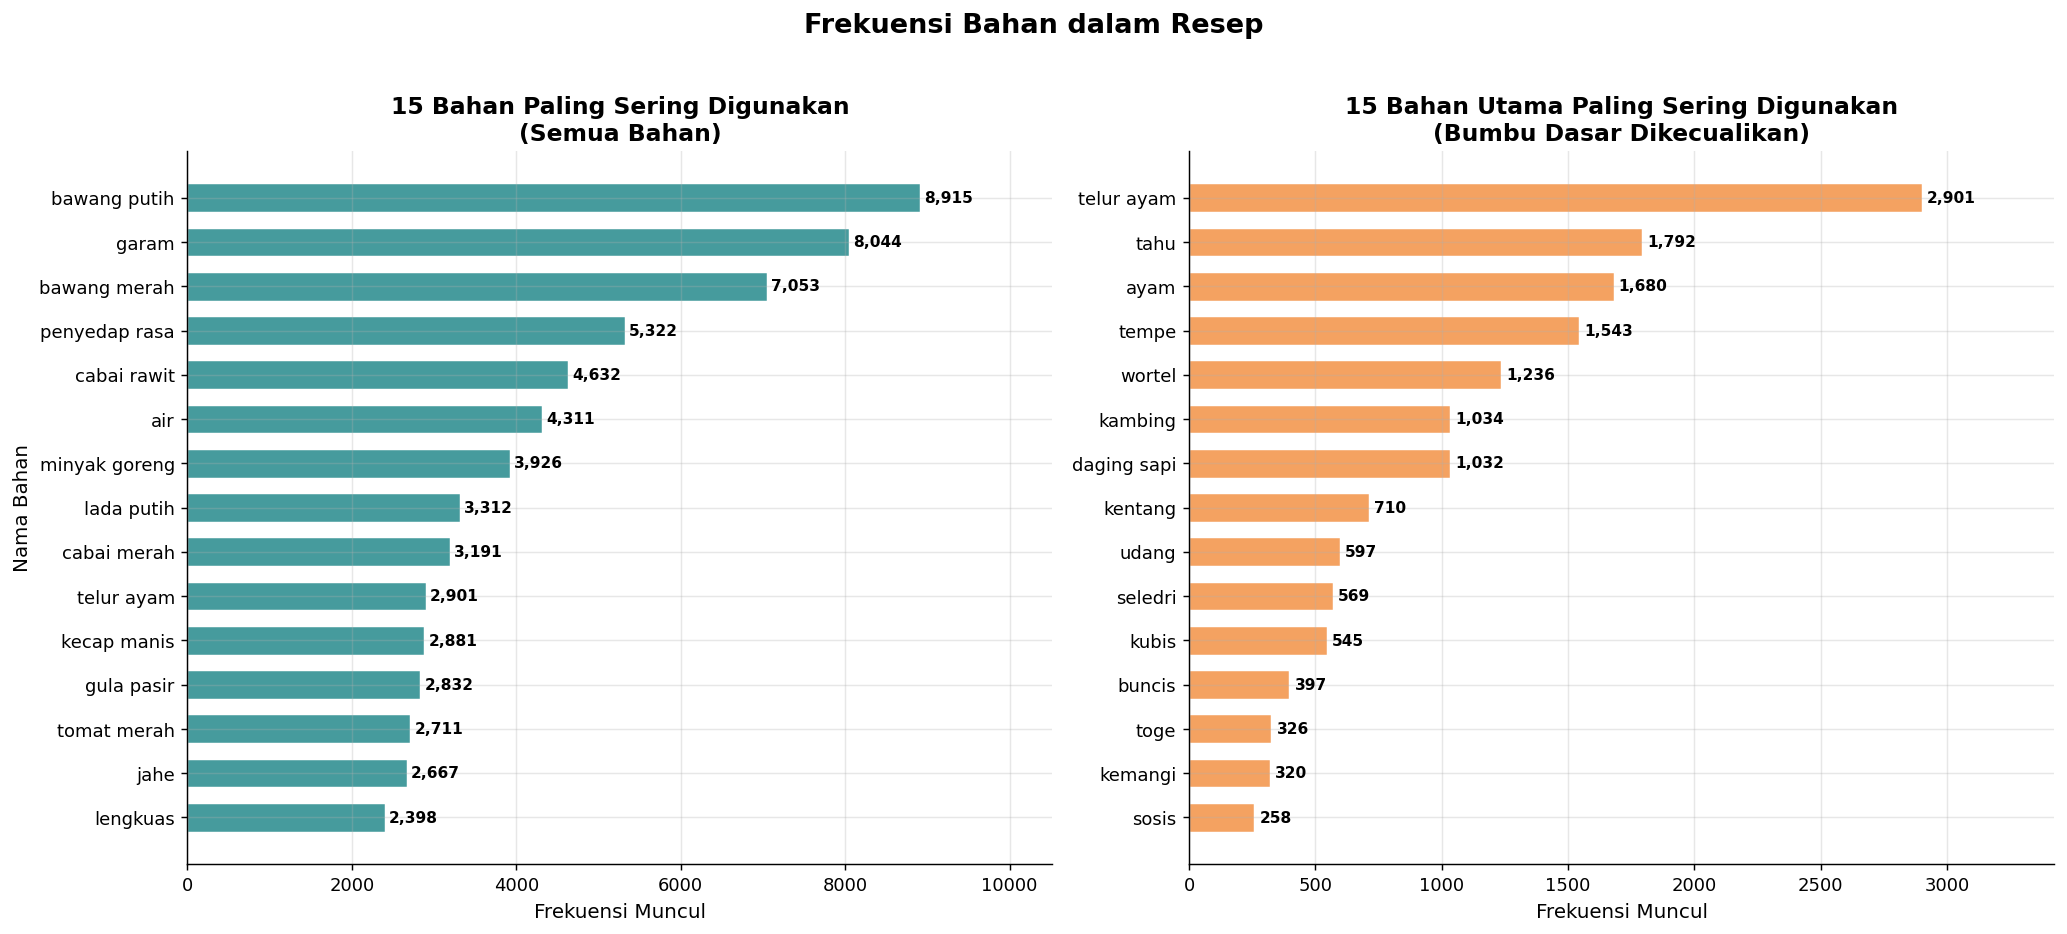

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Chart Kiri: Semua Bahan ---
top15_semua = df_bahan_freq.head(15)
axes[0].barh(top15_semua['bahan'][::-1], top15_semua['frekuensi'][::-1],
             color='#469B9D', edgecolor='white', linewidth=0.8, height=0.65)

for bar, val in zip(axes[0].patches, top15_semua['frekuensi'][::-1]):
    axes[0].text(val + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8.5, fontweight='bold')

axes[0].set_title('15 Bahan Paling Sering Digunakan\n(Semua Bahan)', fontweight='bold')
axes[0].set_xlabel('Frekuensi Muncul')
axes[0].set_ylabel('Nama Bahan')
axes[0].set_xlim(0, top15_semua['frekuensi'].max() * 1.18)

# --- Chart Kanan: Bahan Utama ---
top15_utama = df_bahan_utama.head(15)
axes[1].barh(top15_utama['bahan'][::-1], top15_utama['frekuensi'][::-1],
             color='#F4A261', edgecolor='white', linewidth=0.8, height=0.65)

for bar, val in zip(axes[1].patches, top15_utama['frekuensi'][::-1]):
    axes[1].text(val + 20, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8.5, fontweight='bold')

axes[1].set_title('15 Bahan Utama Paling Sering Digunakan\n(Bumbu Dasar Dikecualikan)', fontweight='bold')
axes[1].set_xlabel('Frekuensi Muncul')
axes[1].set_ylabel('')
axes[1].set_xlim(0, top15_utama['frekuensi'].max() * 1.18)

fig.suptitle('Frekuensi Bahan dalam Resep', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q5_frekuensi_bahan.png', bbox_inches='tight', dpi=150)
plt.show()

Berdasarkan analisis frekuensi bahan dalam resep, bawang putih, garam, dan bawang merah menjadi bahan yang paling sering digunakan dalam masakan Indonesia. Hal ini menunjukkan bahwa sebagian besar resep memiliki pola bumbu dasar yang serupa dan sangat bergantung pada rempah aromatik sebagai fondasi cita rasa masakan. Tingginya penggunaan cabai, lada putih, jahe, dan lengkuas juga mencerminkan karakter kuliner Indonesia yang kaya bumbu dan cenderung bercita rasa kuat.

Sementara itu, setelah bumbu dasar dikecualikan, bahan utama yang paling sering digunakan adalah telur ayam, tahu, ayam, dan tempe. Hasil ini menunjukkan bahwa sumber protein yang praktis, ekonomis, dan mudah diolah menjadi bahan utama favorit dalam masakan sehari-hari. Selain itu, munculnya sayuran seperti wortel, kentang, dan kubis menunjukkan bahwa banyak resep Indonesia mengombinasikan protein dengan sayuran pelengkap.Hal ini dapat dimanfaatkan dalam sistem rekomendasi resep karena bahan dengan frekuensi tinggi cenderung lebih umum tersedia di rumah tangga pengguna, sehingga rekomendasi yang diberikan dapat menjadi lebih relevan dan realistis untuk dimasak sehari-hari.

## 📊 6 — Rata-Rata Jumlah Bahan per Resep

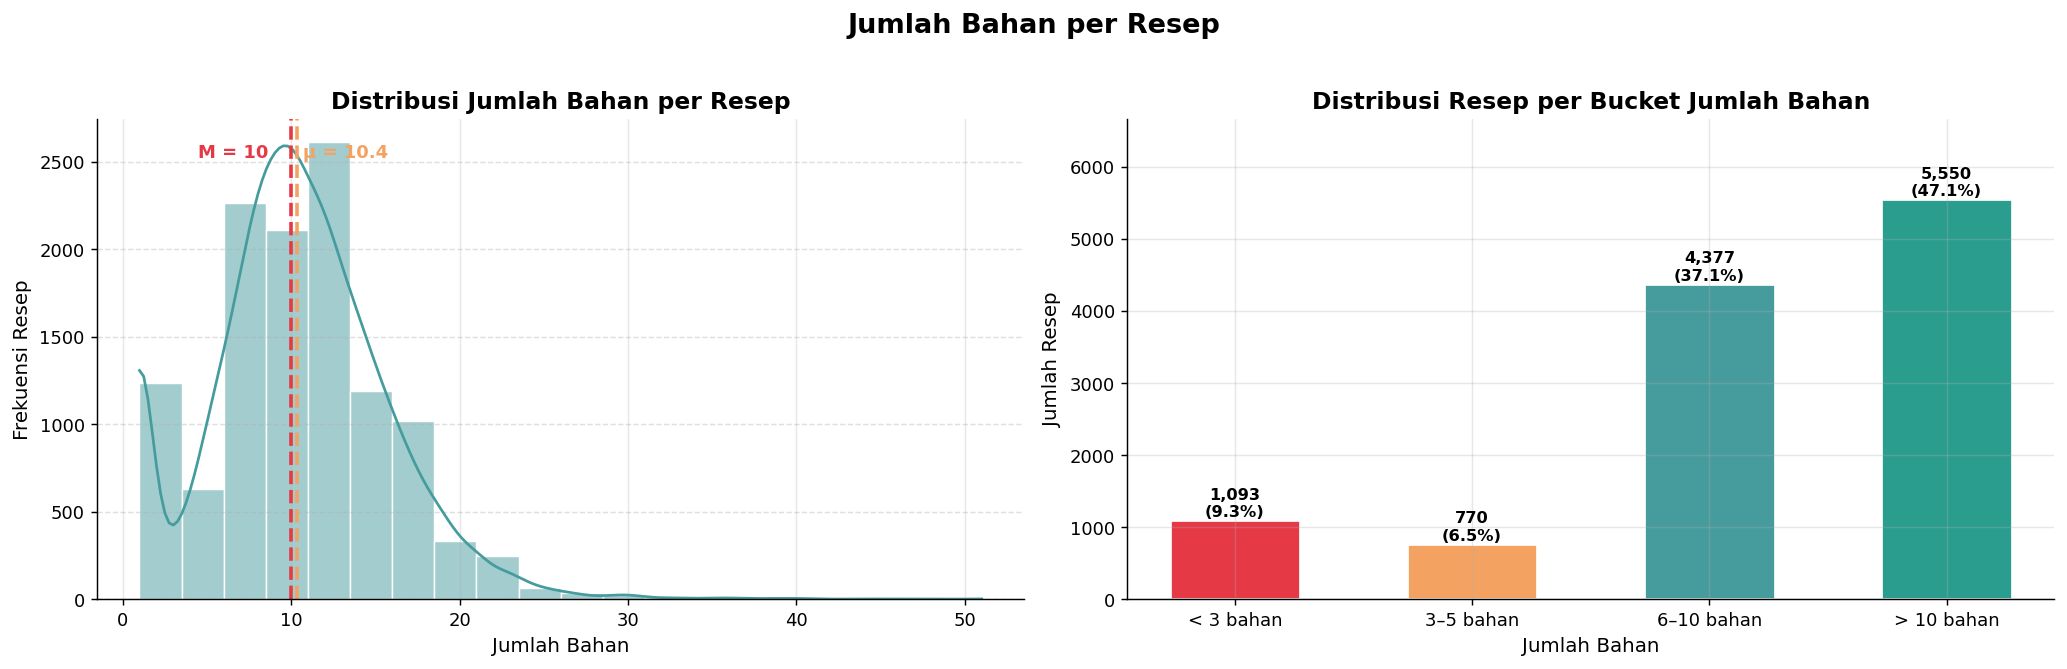

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

jumlah_bahan = df_grouped['jumlah_bahan']

# --- Plot 1: Histogram dengan ikon ---
sns.histplot(jumlah_bahan, kde=True, bins=20, color='#469B9D',
             edgecolor='white', linewidth=0.8, ax=axes[0])

y_max = axes[0].get_ylim()[1]

# Rata-rata dengan ikon μ
axes[0].axvline(jumlah_bahan.mean(), color=COLOR_WARNING, linestyle='--', linewidth=2)
axes[0].text(jumlah_bahan.mean() + 0.3, y_max * 0.92,
             f'μ = {jumlah_bahan.mean():.1f}',
             fontsize=10, color=COLOR_WARNING, fontweight='bold')

# Median dengan ikon M
axes[0].axvline(jumlah_bahan.median(), color=COLOR_DANGER, linestyle='--', linewidth=2)
axes[0].text(jumlah_bahan.median() - 5.5, y_max * 0.92,
             f'M = {jumlah_bahan.median():.0f}',
             fontsize=10, color=COLOR_DANGER, fontweight='bold')

axes[0].set_title('Distribusi Jumlah Bahan per Resep', fontweight='bold')
axes[0].set_xlabel('Jumlah Bahan')
axes[0].set_ylabel('Frekuensi Resep')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# --- Plot 2: Bucket ---
buckets = {
    '< 3 bahan'  : (jumlah_bahan < 3).sum(),
    '3–5 bahan'  : ((jumlah_bahan >= 3) & (jumlah_bahan <= 5)).sum(),
    '6–10 bahan' : ((jumlah_bahan >= 6) & (jumlah_bahan <= 10)).sum(),
    '> 10 bahan' : (jumlah_bahan > 10).sum()
}
bucket_colors = [COLOR_DANGER, COLOR_WARNING, '#469B9D', COLOR_SAFE]
bars = axes[1].bar(buckets.keys(), buckets.values(),
                   color=bucket_colors, edgecolor='white',
                   linewidth=1.5, width=0.55)

for bar, val in zip(bars, buckets.values()):
    pct = val / len(jumlah_bahan) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({pct:.1f}%)', ha='center',
                 fontsize=9, fontweight='bold')

axes[1].set_title('Distribusi Resep per Bucket Jumlah Bahan', fontweight='bold')
axes[1].set_xlabel('Jumlah Bahan')
axes[1].set_ylabel('Jumlah Resep')
axes[1].set_ylim(0, max(buckets.values()) * 1.2)

fig.suptitle('Jumlah Bahan per Resep', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q6_jumlah_bahan.png', bbox_inches='tight', dpi=150)
plt.show()

Berdasarkan distribusi jumlah bahan per resep, rata-rata resep menggunakan sekitar 10,4 bahan dengan median 10 bahan. Kedekatan antara mean dan median menunjukkan bahwa sebagian besar resep berada pada tingkat kompleksitas menengah, meskipun terdapat beberapa resep dengan jumlah bahan sangat banyak yang menyebabkan distribusi sedikit condong ke kanan (right-skewed).

Selain itu, distribusi bucket jumlah bahan menunjukkan bahwa mayoritas resep berada pada kategori 6–10 bahan (37,1%) dan lebih dari 10 bahan (47,1%). Sementara itu, resep sederhana dengan kurang dari 5 bahan hanya mencakup sebagian kecil dari keseluruhan dataset.

Hasil ini menunjukkan bahwa sebagian besar resep Indonesia cenderung menggunakan bahan yang cukup beragam dan kompleks. Temuan ini penting dalam pengembangan sistem rekomendasi resep karena jumlah bahan dapat memengaruhi tingkat kesulitan memasak, waktu persiapan, serta kemungkinan ketersediaan bahan di rumah tangga pengguna.

# **Kesimpulan**
Berdasarkan keseluruhan analisis, metode penyimpanan terbukti memiliki pengaruh yang signifikan terhadap umur simpan bahan makanan. Penyimpanan menggunakan freezer memberikan umur simpan paling panjang dibanding kulkas maupun suhu ruangan, sehingga dapat menjadi strategi utama untuk mengurangi risiko food waste pada bahan yang mudah rusak.

Selain metode penyimpanan, jenis kategori bahan juga sangat memengaruhi ketahanan bahan makanan. Kategori seperti hidangan laut dan daging memiliki umur simpan paling pendek sehingga perlu diprioritaskan untuk segera diolah, sedangkan bahan shelf-stable seperti makanan tahan lama di rak, pasta, dan makanan kalengan memiliki umur simpan jauh lebih panjang.

Analisis resep menunjukkan bahwa masakan Indonesia didominasi oleh penggunaan bumbu dasar seperti bawang putih, bawang merah, garam, dan cabai, sementara bahan utama yang paling sering digunakan adalah telur ayam, tahu, ayam, dan tempe. Hal ini menunjukkan bahwa sebagian besar resep menggunakan bahan yang umum tersedia di rumah tangga Indonesia sehingga cocok digunakan dalam sistem rekomendasi resep berbasis stok bahan.

Selain itu, mayoritas resep memiliki kompleksitas menengah dengan rata-rata sekitar 10 bahan per resep. Temuan ini menunjukkan bahwa sistem rekomendasi resep perlu mempertimbangkan jumlah bahan agar rekomendasi tetap realistis, praktis, dan mudah dimasak oleh pengguna.

Secara keseluruhan, hasil analisis ini mendukung pengembangan sistem SisaBisa yang mampu:

Mengestimasi umur simpan bahan berdasarkan metode penyimpanan,
Menentukan prioritas bahan yang harus segera digunakan,
Mengurangi potensi food waste,
Memberikan rekomendasi resep yang relevan berdasarkan bahan yang tersedia dan tingkat kompleksitas resep.